# Shock Distribution Explorer
Four visualization options for per-robot acceleration data. Run the **Data Loading** cell first, then pick whichever plot you like.

## Data Loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ── Shock penalty parameters (must match crossing_env.py) ────────────────────
THRESHOLD = 11.0   # m/s²  — deadzone below this
SCALE     = 10.0   # m/s²  — full penalty at THRESHOLD + SCALE

def shock_norm(a):
    return np.clip((a - THRESHOLD) / SCALE, 0.0, 1.0)

# ── Search paths ─────────────────────────────────────────────────────────────
WS = Path('/home/robot/workspaces/robot_rodeo_gym_ws')

# Override: set to a path relative to WS to load from one specific run or study.
DATA_OVERRIDE = None

if DATA_OVERRIDE:
    override_path = WS / DATA_OVERRIDE
    if not override_path.exists():
        raise FileNotFoundError(f'DATA_OVERRIDE path does not exist: {override_path}')
    SEARCH_DIRS = [override_path]
    print(f'Loading from: {override_path}')
else:
    SEARCH_DIRS = [WS / 'runs', WS / 'logs']
    print('Loading from all runs/ and logs/')

# ── Streaming histogram — never loads all data into RAM ──────────────────────
# Each NPZ is read once, accumulated into a histogram, then freed.
HIST_RANGE    = (0.0, 200.0)
HIST_BINS     = 4000           # 0.05 m/s² resolution
SUBSAMPLE_MAX = 2_000_000      # cap kept in RAM for KDE (plots 2/3)

hist_counts = np.zeros(HIST_BINS, dtype=np.int64)
hist_edges  = np.linspace(HIST_RANGE[0], HIST_RANGE[1], HIST_BINS + 1)
sub_chunks  = []
sub_total   = 0
raw_total   = 0
rng         = np.random.default_rng(42)

for d in SEARCH_DIRS:
    for f in sorted(d.rglob('raw_accel.npz')):
        try:
            arr = np.load(f)['accel']
            arr = arr[(arr >= 0) & (arr < 200)].astype(np.float32)
            n   = len(arr)
            raw_total += n
            c, _ = np.histogram(arr, bins=HIST_BINS, range=HIST_RANGE)
            hist_counts += c
            if sub_total < SUBSAMPLE_MAX:
                take = min(n, SUBSAMPLE_MAX - sub_total)
                idx  = rng.choice(n, size=take, replace=False)
                sub_chunks.append(arr[idx])
                sub_total += take
            print(f'  NPZ  {f}  ({n:,} samples)')
        except Exception as e:
            print(f'  SKIP {f}: {e}')

raw_sample = np.concatenate(sub_chunks) if sub_chunks else None
raw_hist   = (hist_counts, hist_edges)   # (counts[N], edges[N+1])

if raw_total:
    print(f'\nNPZ total: {raw_total:,}  |  histogram bins: {HIST_BINS}  |  subsample: {sub_total:,}')
else:
    print('No raw_accel.npz files found.')

# ── Histogram utility functions ───────────────────────────────────────────────
def hist_percentile(counts, edges, p):
    cdf = np.cumsum(counts) / counts.sum()
    idx = min(np.searchsorted(cdf, p / 100.0), len(edges) - 2)
    return float(edges[idx])

def hist_mean(counts, edges):
    centers = 0.5 * (edges[:-1] + edges[1:])
    return float(np.sum(centers * counts) / counts.sum())

def hist_frac_above(counts, edges, threshold):
    centers = 0.5 * (edges[:-1] + edges[1:])
    return float(counts[centers > threshold].sum() / counts.sum())

# ── Load step-mean / step-max from shock.csv ─────────────────────────────────
means_list, maxes_list = [], []
for d in SEARCH_DIRS:
    for csv in sorted(d.rglob('shock.csv')):
        try:
            df = pd.read_csv(csv)
            if 'shock/accel_magnitude' in df.columns:
                means_list.append(df['shock/accel_magnitude'].dropna().values)
            if 'shock/accel_magnitude_max' in df.columns:
                maxes_list.append(df['shock/accel_magnitude_max'].dropna().values)
            print(f'  CSV  {csv}')
        except Exception as e:
            print(f'  SKIP {csv}: {e}')

csv_means = np.concatenate(means_list) if means_list else np.array([])
csv_maxes = np.concatenate(maxes_list) if maxes_list else np.array([])
csv_means = csv_means[csv_means < 200]
csv_maxes = csv_maxes[csv_maxes < 200]
print(f'\nCSV step-mean: {len(csv_means):,} samples,  step-max: {len(csv_maxes):,} samples')

Loading from all runs/ and logs/
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/runs/best_so_far/TheAshape/raw_accel.npz  (30,629,507 samples)
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna_ftr_10905205/optuna_ftr_10905205_17/raw_accel.npz  (10,444,081 samples)
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna_ftr_10905205/optuna_ftr_10905205_18/raw_accel.npz  (7,166,060 samples)
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna_ftr_10905205/optuna_ftr_10905205_19/raw_accel.npz  (9,061,942 samples)
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna_ftr_10905205/optuna_ftr_10905205_20/raw_accel.npz  (46,076,958 samples)
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna_ftr_10905205/optuna_ftr_10905205_21/raw_accel.npz  (10,955,970 samples)
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna_ftr_10905205/optuna_ftr_10905205_22/raw_accel.npz  (1,125,914 samples)
  NPZ  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna

---
## Plot 1 — CSV fallback: step-mean and step-max histograms
Uses averaged-across-1024-robots values per step. **Misleading for tail behaviour** — a 50 m/s² impact contributes only ~0.05 m/s² to the mean.

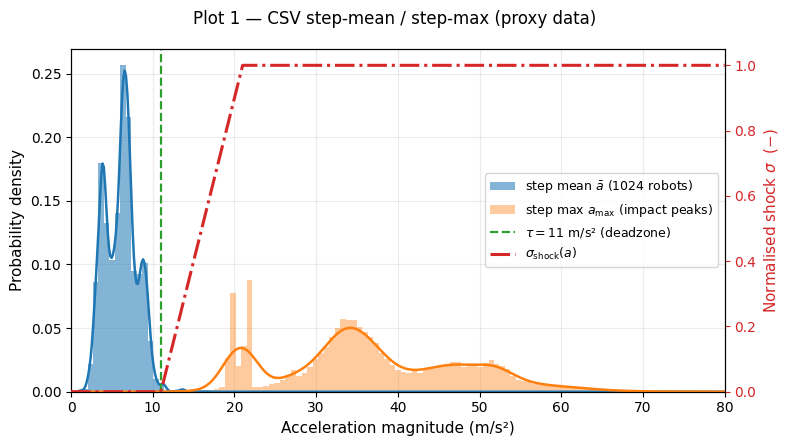

In [2]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 80, 120)
xs   = np.linspace(0, 80, 500)

if len(csv_means):
    ax1.hist(csv_means, bins=bins, density=True, alpha=0.55,
             color='#1f77b4', label=r'step mean $\bar{a}$ (1024 robots)', zorder=2)
    kde_m = gaussian_kde(csv_means[csv_means < 80], bw_method=0.15)
    ax1.plot(xs, kde_m(xs), color='#1f77b4', linewidth=1.8, zorder=3)

if len(csv_maxes):
    ax1.hist(csv_maxes, bins=bins, density=True, alpha=0.40,
             color='#ff7f0e', label=r'step max $a_{\mathrm{max}}$ (impact peaks)', zorder=2)
    kde_M = gaussian_kde(csv_maxes[csv_maxes < 80], bw_method=0.15)
    ax1.plot(xs, kde_M(xs), color='#ff7f0e', linewidth=1.8, zorder=3)

ax1.axvline(THRESHOLD, color='#2ca02c', linestyle='--', linewidth=1.6,
            label=rf'$\tau = {THRESHOLD:.0f}$ m/s² (deadzone)', zorder=5)
ax1.set_xlabel(r'Acceleration magnitude (m/s²)', fontsize=11)
ax1.set_ylabel('Probability density', fontsize=11)
ax1.set_xlim(0, 80)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(xs, shock_norm(xs), color='#d62728', linewidth=2.2, linestyle='-.',
         label=r'$\sigma_{\mathrm{shock}}(a)$', zorder=4)
ax2.set_ylabel(r'Normalised shock $\sigma$  (−)', fontsize=11, color='#d62728')
ax2.tick_params(axis='y', colors='#d62728')
ax2.set_ylim(0, 1.05)

lines = ax1.get_legend_handles_labels()
lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0]+lines2[0], lines[1]+lines2[1], fontsize=9, loc='right')
ax1.grid(True, alpha=0.25)
fig.suptitle('Plot 1 — CSV step-mean / step-max (proxy data)', fontsize=12)
fig.tight_layout()
plt.show()

---
## Plot 2 — Raw NPZ: linear y-axis
True per-robot samples. Tail near zero because of linear scale — hard to read beyond ~20 m/s².

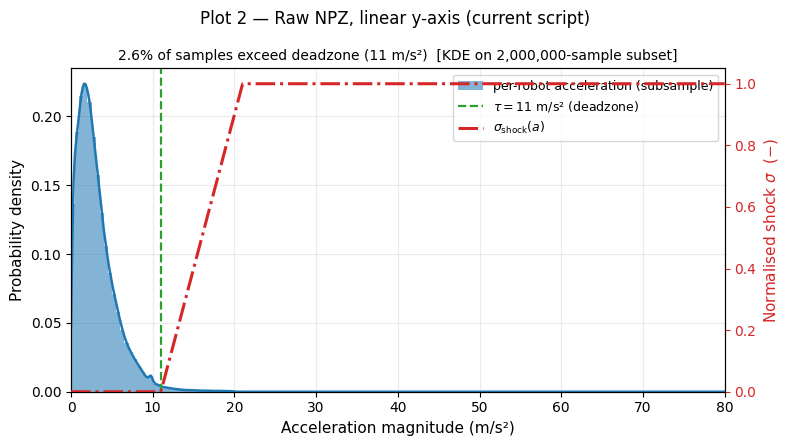

In [3]:
assert raw_sample is not None, 'No raw_accel.npz data found — run data loading cell first'

fig, ax1 = plt.subplots(figsize=(8, 4.5))
bins_plot = np.linspace(0, 80, 160)
xs        = np.linspace(0, 80, 500)

sub80 = raw_sample[raw_sample < 80]
ax1.hist(sub80, bins=bins_plot, density=True, alpha=0.55,
         color='#1f77b4', label='per-robot acceleration (subsample)', zorder=2)
kde = gaussian_kde(sub80, bw_method=0.06)
ax1.plot(xs, kde(xs), color='#1f77b4', linewidth=1.8, zorder=3)

ax1.axvline(THRESHOLD, color='#2ca02c', linestyle='--', linewidth=1.6,
            label=rf'$\tau = {THRESHOLD:.0f}$ m/s² (deadzone)', zorder=5)
ax1.set_xlabel(r'Acceleration magnitude (m/s²)', fontsize=11)
ax1.set_ylabel('Probability density', fontsize=11)
ax1.set_xlim(0, 80)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(xs, shock_norm(xs), color='#d62728', linewidth=2.2, linestyle='-.',
         label=r'$\sigma_{\mathrm{shock}}(a)$', zorder=4)
ax2.set_ylabel(r'Normalised shock $\sigma$  (−)', fontsize=11, color='#d62728')
ax2.tick_params(axis='y', colors='#d62728')
ax2.set_ylim(0, 1.05)

pct_above = 100 * hist_frac_above(*raw_hist, THRESHOLD)
ax1.set_title(f'{pct_above:.1f}% of samples exceed deadzone ({THRESHOLD:.0f} m/s²)  '
              f'[KDE on {len(sub80):,}-sample subset]', fontsize=10)

lines = ax1.get_legend_handles_labels()
lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0]+lines2[0], lines[1]+lines2[1], fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.25)
fig.suptitle('Plot 2 — Raw NPZ, linear y-axis (current script)', fontsize=12)
fig.tight_layout()
plt.show()

---
## Plot 3 — Raw NPZ: log y-axis
Same data as Plot 2 but log-scale reveals the tail. KDE replaced with histogram only (KDE can go negative which breaks log scale).

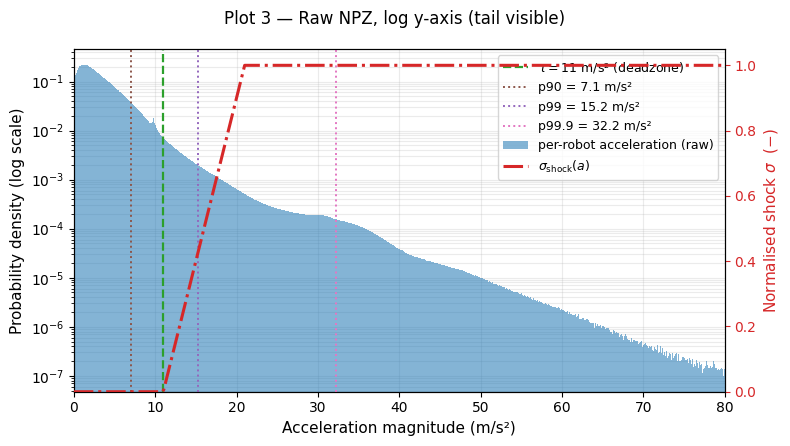

In [4]:
assert raw_total > 0, 'No raw_accel.npz data found — run data loading cell first'

counts, edges = raw_hist
centers = 0.5 * (edges[:-1] + edges[1:])
mask80  = centers < 80
total   = counts.sum()
width   = edges[1] - edges[0]

# Normalise to probability density; replace zero bins with NaN so log scale works
density = np.where(counts[mask80] > 0, counts[mask80] / (total * width), np.nan)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
xs = np.linspace(0, 80, 500)

ax1.bar(centers[mask80], density, width=width, alpha=0.55, color='#1f77b4',
        label='per-robot acceleration (raw)', zorder=2)

ax1.axvline(THRESHOLD, color='#2ca02c', linestyle='--', linewidth=1.6,
            label=rf'$\tau = {THRESHOLD:.0f}$ m/s² (deadzone)', zorder=5)
ax1.set_yscale('log')
ax1.set_xlabel(r'Acceleration magnitude (m/s²)', fontsize=11)
ax1.set_ylabel('Probability density (log scale)', fontsize=11)
ax1.set_xlim(0, 80)

ax2 = ax1.twinx()
ax2.plot(xs, shock_norm(xs), color='#d62728', linewidth=2.2, linestyle='-.',
         label=r'$\sigma_{\mathrm{shock}}(a)$', zorder=4)
ax2.set_ylabel(r'Normalised shock $\sigma$  (−)', fontsize=11, color='#d62728')
ax2.tick_params(axis='y', colors='#d62728')
ax2.set_ylim(0, 1.05)

for pct, color in [(90, '#8c564b'), (99, '#9467bd'), (99.9, '#e377c2')]:
    val = hist_percentile(counts, edges, pct)
    ax1.axvline(val, color=color, linestyle=':', linewidth=1.4,
                label=f'p{pct} = {val:.1f} m/s²', zorder=4)

lines = ax1.get_legend_handles_labels()
lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0]+lines2[0], lines[1]+lines2[1], fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.25, which='both')
fig.suptitle('Plot 3 — Raw NPZ, log y-axis (tail visible)', fontsize=12)
fig.tight_layout()
plt.show()

---
## Plot 4 — CCDF: P(accel > x)
Complementary CDF — reads directly as *"fraction of robot-timesteps experiencing at least X m/s²"*. Most informative for motivating the shock penalty threshold and saturation point.

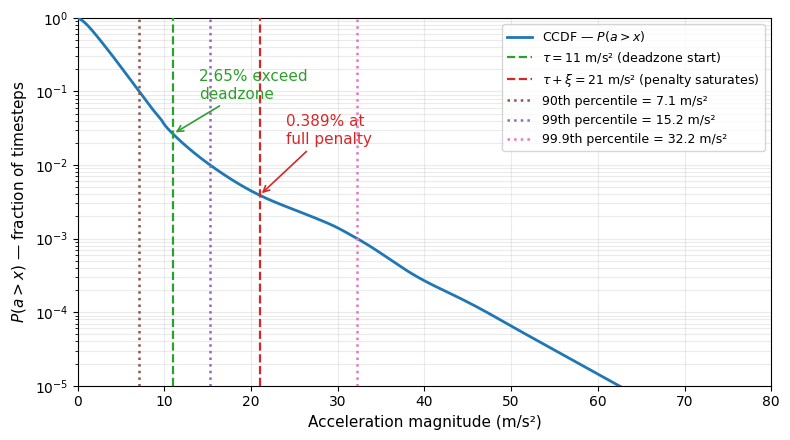

In [5]:
assert raw_total > 0, 'No raw_accel.npz data found — run data loading cell first'

counts, edges = raw_hist
centers = 0.5 * (edges[:-1] + edges[1:])
ccdf    = 1.0 - np.cumsum(counts) / counts.sum()

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(centers, np.maximum(ccdf, 1e-7), color='#1f77b4', linewidth=2.0,
         label=r'CCDF — $P(a > x)$', zorder=3)
ax1.set_yscale('log')

ax1.axvline(THRESHOLD, color='#2ca02c', linestyle='--', linewidth=1.6,
            label=rf'$\tau = {THRESHOLD:.0f}$ m/s² (deadzone start)', zorder=5)
sat = THRESHOLD + SCALE
ax1.axvline(sat, color='#d62728', linestyle='--', linewidth=1.6,
            label=rf'$\tau + \xi = {sat:.0f}$ m/s² (penalty saturates)', zorder=5)

frac_above = hist_frac_above(counts, edges, THRESHOLD)
frac_sat   = hist_frac_above(counts, edges, sat)
ax1.annotate(f'{100*frac_above:.2f}% exceed\ndeadzone',
             xy=(THRESHOLD, frac_above), xytext=(THRESHOLD + 3, frac_above * 3),
             fontsize=11, color='#2ca02c',
             arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.2))
if frac_sat > 0:
    ax1.annotate(f'{100*frac_sat:.3f}% at\nfull penalty',
                 xy=(sat, max(frac_sat, 1e-6)), xytext=(sat + 3, max(frac_sat, 1e-6) * 5),
                 fontsize=11, color='#d62728',
                 arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.2))

for pct, color in [(90, '#8c564b'), (99, '#9467bd'), (99.9, '#e377c2')]:
    val = hist_percentile(counts, edges, pct)
    ax1.axvline(val, color=color, linestyle=':', linewidth=1.8,
                label=f'{pct}th percentile = {val:.1f} m/s²', zorder=4)

ax1.set_xlabel(r'Acceleration magnitude (m/s²)', fontsize=11)
ax1.set_ylabel(r'$P(a > x)$ — fraction of timesteps', fontsize=11)
ax1.set_xlim(0, 80)
ax1.set_ylim(1e-5, 1.0)
ax1.grid(True, alpha=0.25, which='both')
ax1.legend(fontsize=9, loc='upper right')
fig.tight_layout()
plt.show()

---
## Key statistics

In [6]:
if raw_total > 0:
    counts, edges = raw_hist
    print(f'Total raw samples : {raw_total:,}')
    print(f'Mean              : {hist_mean(counts, edges):.2f} m/s²')
    print(f'Median (p50)      : {hist_percentile(counts, edges, 50):.2f} m/s²')
    print(f'p90               : {hist_percentile(counts, edges, 90):.2f} m/s²')
    print(f'p99               : {hist_percentile(counts, edges, 99):.2f} m/s²')
    print(f'p99.9             : {hist_percentile(counts, edges, 99.9):.2f} m/s²')
    print(f'Max (p100)        : {hist_percentile(counts, edges, 100):.2f} m/s²')
    print()
    print(f'Above threshold ({THRESHOLD:.0f} m/s²) : {100*hist_frac_above(counts, edges, THRESHOLD):.3f}%')
    print(f'Above saturation ({THRESHOLD+SCALE:.0f} m/s²)  : {100*hist_frac_above(counts, edges, THRESHOLD+SCALE):.4f}%')

Total raw samples : 6,088,485,800
Mean              : 3.44 m/s²
Median (p50)      : 2.55 m/s²
p90               : 7.05 m/s²
p99               : 15.25 m/s²
p99.9             : 32.25 m/s²
Max (p100)        : 198.75 m/s²

Above threshold (11 m/s²) : 2.647%
Above saturation (21 m/s²)  : 0.3886%
